<a href="https://www.kaggle.com/code/viktorkondrashov123/homework19?scriptVersionId=294572035" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [3]:
dataset = datasets.ImageFolder(data_dir)

In [4]:
len(dataset)

16854

In [5]:
img, label = dataset[123]

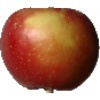

In [6]:
img

In [7]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [8]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])  # 80% на 20%

In [9]:
len(train_dataset)


13484

In [10]:
len(test_dataset)


3370

In [11]:
img, label = train_dataset[5000]

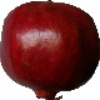

In [12]:
img

In [13]:
train_dataset[0]

(<PIL.Image.Image image mode=RGB size=100x100>, 23)

In [14]:
test_dataset[0]

(<PIL.Image.Image image mode=RGB size=100x100>, 18)

In [15]:
from torch.utils.data import Dataset

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [16]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(100),
    transforms.ToTensor()
    ]
)

In [17]:
test_transform = transforms.Compose(
    [transforms.Resize([224,224]),
    transforms.ToTensor()
    ]
)

In [18]:
train_dataset = TransformDataset(train_dataset, train_transform)
test_dataset = TransformDataset(test_dataset, test_transform)

In [19]:
train_dataset[20]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 9)

In [20]:
test_dataset[0]

(tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          [0.9961, 0.9961, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[0.9804, 0.9804, 0.9804,  ..., 1.0000, 1.0000, 1.0000],
          [0.9804, 0.9804, 0.9804,  ..., 1.0000, 1.0000, 1.0000],
          [0.9804, 0.9804, 0.9804,  ...,

In [21]:
batch_size = 128

# Створіть завантажувачі даних
train_loader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, shuffle=True, batch_size=batch_size)

In [22]:
for img, label in train_loader:
    break

img.shape

torch.Size([128, 3, 224, 224])

In [23]:
label

tensor([12, 25,  0, 14,  4,  4, 26,  1, 27, 22, 11,  3,  7, 14, 24, 22,  8, 17,
        18, 25,  0,  9, 22,  4,  6, 23, 13,  2, 25, 26, 21, 25, 13, 31, 11, 22,
        29, 24, 15,  7, 23, 24, 21,  0, 29, 15,  4, 31, 20,  9, 19,  8, 12, 12,
        19, 23,  4, 20, 24, 24,  4,  9,  7, 22, 24, 27, 29, 29, 24,  3, 12,  9,
        20,  4,  7,  6, 19,  3, 22,  4, 11, 28, 12,  9, 14, 12, 25, 16,  2, 18,
        15, 14, 28, 22,  8, 22,  4, 19, 10,  0,  0, 24,  7, 13, 26, 25, 20, 15,
         6, 22, 20, 15, 14, 10,  1,  9, 27,  6,  8, 27, 20,  6, 18, 32, 26,  5,
        20,  9])

In [24]:
# назви
X, y = dataset[123]

# Х -- це дані які ви "згодувуєте" моделі
# y -- правильна відповідь

In [25]:
for X_batch, y_batch in train_loader:
    break

(224, 224, 3)


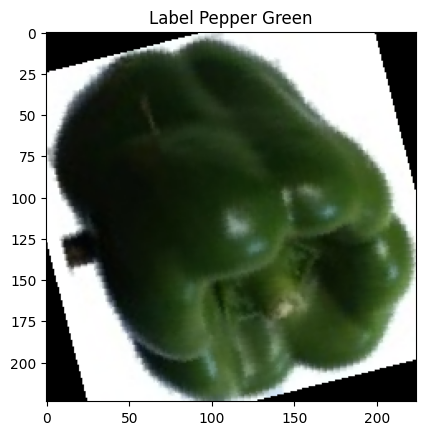

(224, 224, 3)


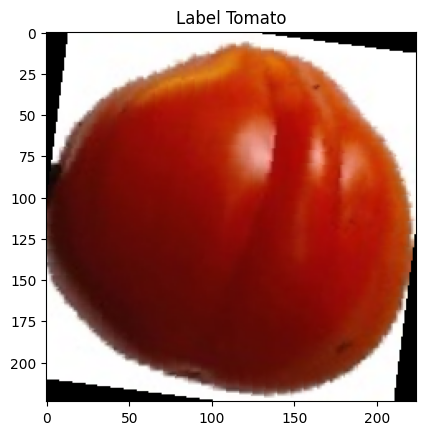

(224, 224, 3)


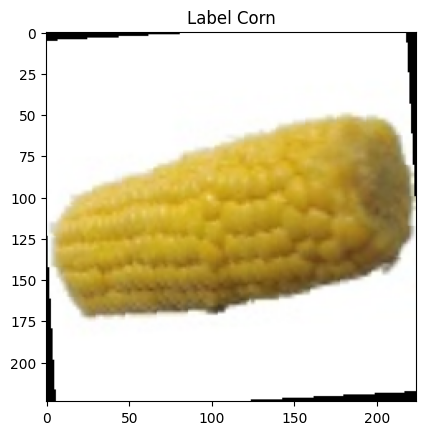

In [26]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_dataset[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

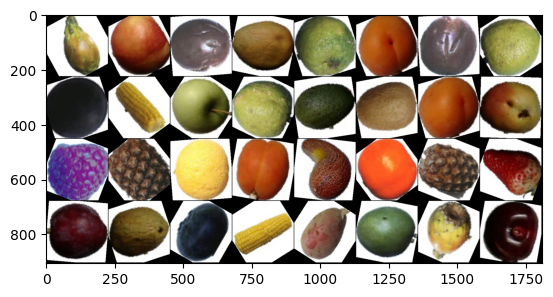

In [27]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [28]:
batch.shape

torch.Size([32, 3, 224, 224])

In [29]:
img, y = train_dataset[0]
img.shape

torch.Size([3, 224, 224])

In [30]:
y

23

In [31]:
3*224*224

150528

In [32]:
len(dataset.classes)

33

In [33]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),  
    nn.Linear(150528, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 33)
)

# підключення до процесора
device = 'cuda'
model = model.to(device)

In [34]:
img = img.unsqueeze(0).to(device)
result = model(img)
result

tensor([[ 0.0033,  0.0407, -0.1302,  0.0385,  0.1143,  0.0614, -0.1299,  0.0563,
         -0.0754,  0.1771,  0.0610,  0.1754, -0.0738,  0.0040,  0.0864, -0.0829,
         -0.0373, -0.0046,  0.1095, -0.0314, -0.0308, -0.0093, -0.0123, -0.0762,
          0.0322, -0.0364, -0.0457,  0.0676, -0.0133,  0.0809,  0.1752,  0.0257,
          0.0624]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [35]:
probs = nn.Softmax()(result)
probs

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.0298, 0.0309, 0.0261, 0.0308, 0.0333, 0.0316, 0.0261, 0.0314, 0.0275,
         0.0354, 0.0315, 0.0354, 0.0276, 0.0298, 0.0324, 0.0273, 0.0286, 0.0295,
         0.0331, 0.0288, 0.0288, 0.0294, 0.0293, 0.0275, 0.0306, 0.0286, 0.0284,
         0.0318, 0.0293, 0.0322, 0.0354, 0.0305, 0.0316]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [36]:
label

'Corn'

In [37]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нейромережі
    lr=0.001
)

In [38]:
for t in range(10):
    # один крок навчання
    total_loss = 0

    # рухаємось по пакетах даних
    for imgs, labels in train_loader:
        # підключити до device
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        # застосовую нейромережу
        prediction = model(imgs)

        # рахуємо помилку(loss)
        loss = loss_fn(prediction, labels)

        # градієнтний спуск
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.cpu().item()

    print(total_loss)

525.04538667202
138.01428204774857
67.57330441474915
42.17687530815601
33.99455930292606
29.597499385476112
24.940133057534695
22.40307429432869
24.10176805406809
21.48130138963461


In [39]:
result = model(imgs).argmax(dim=-1)
result

tensor([11, 19, 13, 24,  1,  3, 18, 13, 17,  3, 18, 15, 18,  8,  4, 19,  9, 30,
        30, 16, 24, 32, 17, 10, 19, 32,  0, 25,  4, 30, 22, 22, 19, 13,  6, 12,
        23,  9,  6, 29, 32, 11, 17, 27], device='cuda:0')

In [40]:
labels

tensor([11, 19, 13, 24, 15,  3, 18, 13, 17,  3, 18, 15, 18,  8,  4, 19,  9, 30,
        30, 16, 24, 32, 17, 10, 19, 32,  0, 25,  4, 30,  6, 22, 19, 13,  6, 12,
        23,  9,  6, 29, 32, 11, 17, 27], device='cuda:0')

In [41]:
nn.Softmax()(prediction)

tensor([[3.4785e-18, 5.3288e-15, 6.2027e-22,  ..., 1.7659e-01, 1.8376e-20,
         1.4407e-06],
        [7.4066e-09, 3.2553e-06, 1.5686e-04,  ..., 8.0630e-07, 1.3441e-08,
         1.4782e-12],
        [2.1673e-08, 1.0616e-06, 1.6081e-10,  ..., 6.5573e-03, 4.9348e-14,
         4.6598e-06],
        ...,
        [3.7541e-20, 1.5553e-17, 4.8470e-28,  ..., 1.0817e-04, 6.0756e-28,
         9.4775e-03],
        [1.3164e-05, 5.2238e-07, 2.9352e-12,  ..., 3.0794e-05, 4.7319e-15,
         1.6575e-10],
        [1.1934e-02, 5.9330e-21, 5.3575e-17,  ..., 3.9966e-07, 4.7896e-11,
         1.1465e-21]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

[]

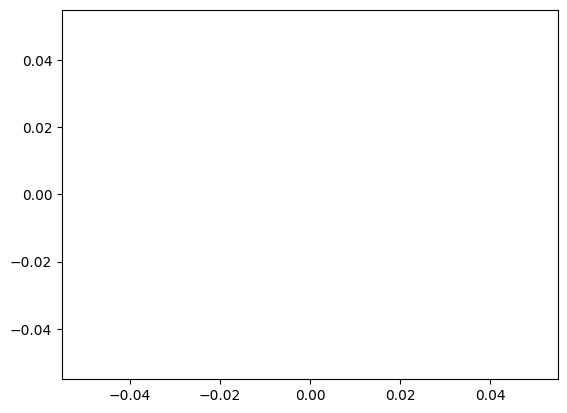

In [42]:
import matplotlib.pyplot as plt

plt.plot()